# Tujuan Praktikum
Praktikum ini bertujuan untuk memahami dan mempraktikkan tahapan persiapan data (data preprocessing) sebelum dimasukkan ke dalam model Machine Learning. Fokus utamanya mencakup pembersihan data (menangani missing value, duplikat, dan outlier), melakukan scaling (standardisasi nilai), serta membaca pola data melalui Exploratory Data Analysis (EDA).

**SOALTugas**

Gunakan satu dataset (bebas, boleh Titanic):

1. Tampilkan ukuran data dan tipe kolom.
2. Tangani missing value dengan alasan yang jelas.
3. Tangani outlier minimal pada 2 kolom numerik.
4. Lakukan scaling pada kolom numerik.
5. Buat minimal 5 visualisasi + 5 insight.

# Pengerjaan Tugas
(*Pada praktikum ini, dataset yang digunakan adalah dataset Titanic bawaan dari library Seaborn*).

# Tugas 1: Ukuran Data dan Tipe Kolom

**Penjelasan Kode:** Langkah pertama adalah memuat dataset Titanic menggunakan fungsi sns.load_dataset("titanic") dari library Seaborn. Setelah data dimuat ke dalam variabel df, dimensi tabel diperiksa menggunakan properti .shape untuk mengetahui jumlah baris dan kolom. Selanjutnya, tipe data dari masing-masing kolom diperiksa menggunakan properti .dtypes.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Memuat dataset Titanic
df = sns.load_dataset("titanic")

print("=== Ukuran Data Awal ===")
print("Shape (baris, kolom):", df.shape)
print("\nTipe kolom:")
print(df.dtypes)

=== Ukuran Data Awal ===
Shape (baris, kolom): (891, 15)

Tipe kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object




**Penjelasan Output:** hasil Shape yang berisi angka untuk jumlah baris dan kolom dari dataset. Di bawahnya, terdapat daftar panjang seluruh nama kolom yang berdampingan dengan tipe datanya masing-masing, seperti float64 (angka desimal), int64 (angka bulat), object (teks), atau category.

# Tugas 2: Menangani Missing Value

**Penjelasan Kode:** Pengecekan data kosong (missing value) dilakukan menggunakan kombinasi .isnull().sum(). Untuk menanganinya, kolom umur (age) diisi menggunakan nilai tengah (median) karena tipe datanya numerik, sedangkan kolom pelabuhan (embarked dan embark_town) diisi dengan nilai yang paling sering muncul (mode) karena bertipe kategorikal. Khusus kolom deck, karena terlalu banyak data yang kosong, diatasi dengan membuat kategori baru bernama "Unknown".

In [2]:
print("=== Missing Value (sebelum) ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Mengisi missing value
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Khusus deck bertipe category, tambahkan kategori baru dulu
df["deck"] = df["deck"].cat.add_categories("Unknown").fillna("Unknown")

print("\n=== Missing Value (sesudah) ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Missing Value (sebelum) ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

=== Missing Value (sesudah) ===
Series([], dtype: int64)


**Penjelasan Output:** bagian "sebelum" menampilkan daftar kolom apa saja yang memiliki data kosong beserta jumlah persisnya. Pada output bagian "sesudah", hasil cetakannya kosong (tidak menampilkan kolom apa pun), yang menandakan bahwa proses pengisian berhasil dan sudah tidak ada lagi data yang missing di dalam DataFrame.

# Tugas 3: Menangani Duplikat dan Outlier

**Penjelasan Kode:** Data duplikat dihapus secara keseluruhan menggunakan fungsi .drop_duplicates(). Untuk menangani nilai ekstrem (outlier) pada kolom fare dan age, digunakan metode Interquartile Range (IQR) dengan mencari nilai kuartil 1 (Q1) dan kuartil 3 (Q3) terlebih dahulu. Nilai yang berada di luar batas bawah (low) dan batas atas (high) kemudian dipotong paksa ke batas terdekat menggunakan fungsi .clip(low, high).

In [3]:
print("=== Duplikat ===")
print("Jumlah duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

print("\n=== Outlier (IQR) ===")
for col in ["fare", "age"]:
    # Menghitung batas IQR
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # Menghitung outlier sebelum dipotong
    outliers_before = ((df[col] < low) | (df[col] > high)).sum()

    # Memotong (clip) nilai yang melewati batas
    df[col] = df[col].clip(low, high)
    print(f"Kolom {col}: {outliers_before} outlier dipotong (batas {low:.1f} – {high:.1f})")

=== Duplikat ===
Jumlah duplikat: 110

=== Outlier (IQR) ===
Kolom fare: 102 outlier dipotong (batas -30.9 – 73.0)
Kolom age: 39 outlier dipotong (batas 1.0 – 57.0)


**Penjelasan Output:** mencetak informasi yang menunjukkan berapa banyak baris data identik yang ditemukan sebagai duplikat. Pada bagian bawahnya, tercetak informasi detail untuk kolom fare dan age yang memperlihatkan jumlah outlier yang terdeteksi, lengkap dengan rentang batas bawah dan atas yang diaplikasikan untuk pemotongan nilai.

# Tugas 4: Scaling pada Kolom Numerik

**Penjelasan Kode:** Untuk menyamakan skala rentang angka antar fitur numerik, digunakan StandardScaler dari modul sklearn.preprocessing. Alat ini diinisialisasi ke dalam variabel scaler, kemudian fungsi .fit_transform() langsung diaplikasikan sekaligus ke kolom age dan fare untuk mengubah nilainya agar memiliki rata-rata nol dan standar deviasi satu.

In [4]:
# Inisialisasi scaler
scaler = StandardScaler()

# Melakukan scaling pada kolom age dan fare
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print("=== Statistik Setelah Scaling ===")
print(df[["age", "fare"]].describe().round(3))

=== Statistik Setelah Scaling ===
           age     fare
count  781.000  781.000
mean     0.000   -0.000
std      1.001    1.001
min     -2.170   -1.167
25%     -0.562   -0.812
50%     -0.103   -0.466
75%      0.510    0.333
max      2.117    2.050


**Penjelasan Output:**  Tabel analisis deskriptif statistik singkat untuk kolom age dan fare. Melalui baris mean (rata-rata) pada tabel tersebut, terlihat bahwa angkanya kini sangat mendekati 0, dan baris std (standar deviasi) berada di angka 1, yang membuktikan bahwa proses scaling telah berhasil mengubah proporsi skalanya.

# Tugas 5: Exploratory Data Analysis (EDA)

**Penjelasan Kode:** Proses EDA dilakukan dengan membuat kanvas grafik berukuran 2 baris dan 3 kolom menggunakan plt.subplots(2, 3). Sesuai dengan syarat minimal EDA, grafik yang disajikan meliputi: distribusi target survived, distribusi dua fitur univariate (age dan fare), hubungan bivariate tingkat keselamatan berdasarkan sex dan class, serta Heatmap untuk melihat korelasi antar fitur numerik. Untuk Heatmap, kita perlu menyaring datanya terlebih dahulu menggunakan .select_dtypes() agar hanya kolom berisi angka (numerik) yang dihitung korelasinya menggunakan .corr().

/tmp/ipykernel_659/1498462474.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1, 1], color="teal")


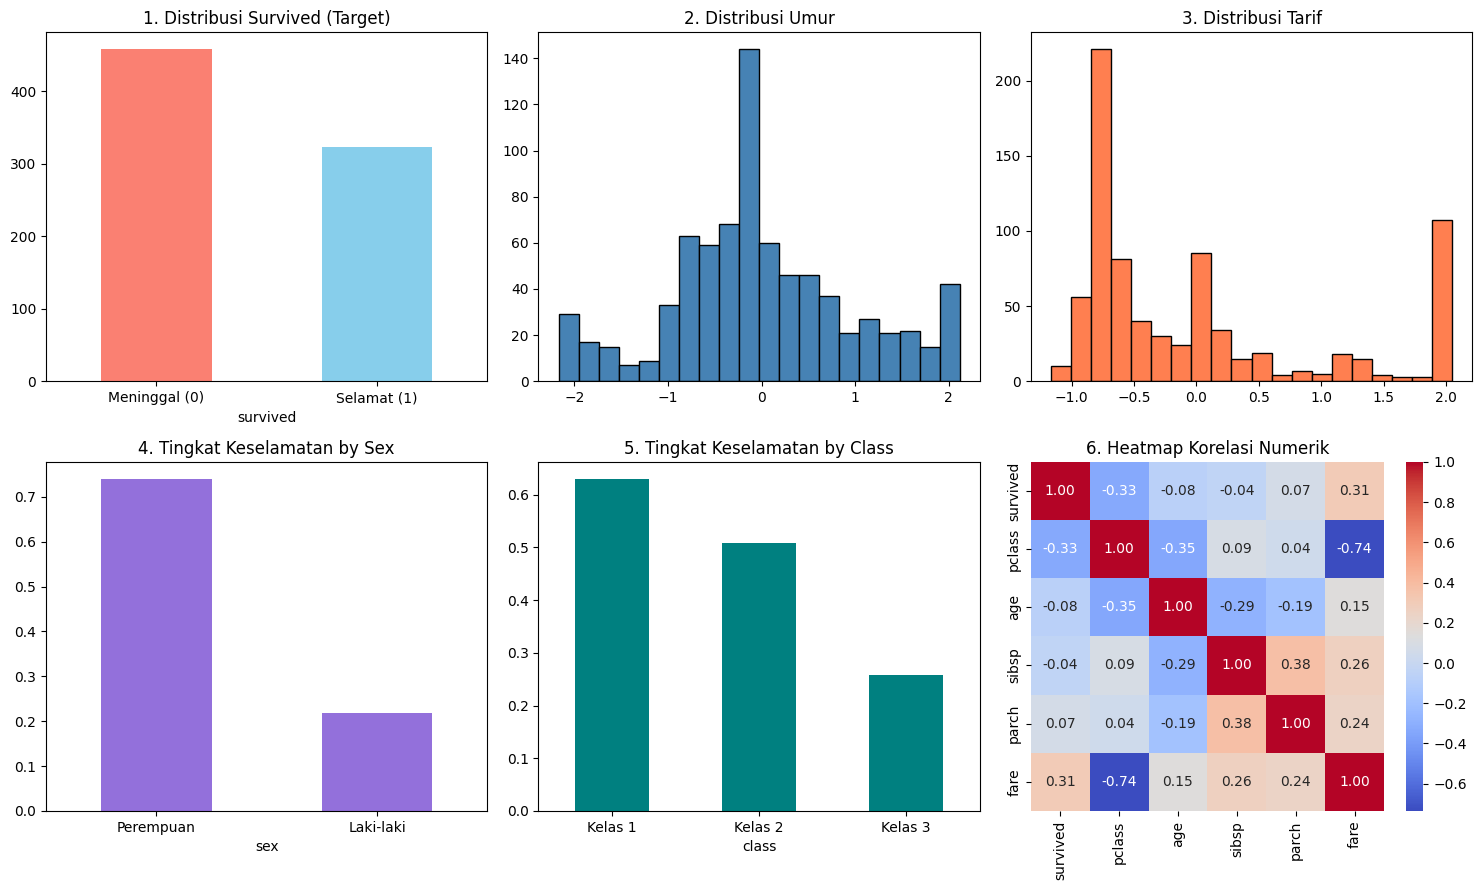

=== 5 Insight (Wawasan Data) ===
1. Tingkat keselamatan keseluruhan hanya mencapai 41.4%.
2. Penumpang perempuan memiliki probabilitas selamat yang sangat tinggi (74.1%) dibanding laki-laki (21.7%).
3. Berdasarkan kelas tiket, penumpang Kelas 1 mencatat tingkat keselamatan tertinggi (63.1%).
4. Berdasarkan Heatmap, fitur 'fare' (tarif) dan 'survived' (selamat) memiliki korelasi positif, yang sejalan dengan insight bahwa penumpang kelas 1 (tarif lebih mahal) lebih banyak yang selamat.
5. Distribusi umur penumpang sebagian besar terkumpul di sekitar nilai tengah (median) karena sebelumnya banyak missing value yang diisi dengan nilai median tersebut.


In [5]:
# Membuat 6 visualisasi dalam satu figure (2 baris, 3 kolom)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Distribusi target (survived)
df["survived"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["salmon", "skyblue"])
axes[0, 0].set_title("1. Distribusi Survived (Target)")
axes[0, 0].set_xticklabels(["Meninggal (0)", "Selamat (1)"], rotation=0)

# 2. Distribusi Umur (Age) - Univariate 1
axes[0, 1].hist(df["age"], bins=20, color="steelblue", edgecolor="black")
axes[0, 1].set_title("2. Distribusi Umur")

# 3. Distribusi Tarif (Fare) - Univariate 2
axes[0, 2].hist(df["fare"], bins=20, color="coral", edgecolor="black")
axes[0, 2].set_title("3. Distribusi Tarif")

# 4. Survival Rate berdasarkan Jenis Kelamin - Bivariate 1
df.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[1, 0], color="mediumpurple")
axes[1, 0].set_title("4. Tingkat Keselamatan by Sex")
axes[1, 0].set_xticklabels(["Perempuan", "Laki-laki"], rotation=0)

# 5. Survival Rate berdasarkan Kelas Penumpang - Bivariate 2
df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("5. Tingkat Keselamatan by Class")
axes[1, 1].set_xticklabels(["Kelas 1", "Kelas 2", "Kelas 3"], rotation=0)

# 6. Heatmap Korelasi Fitur Numerik
# Menyaring hanya kolom yang bernilai angka
kolom_numerik = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(kolom_numerik.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("6. Heatmap Korelasi Numerik")

plt.tight_layout()
plt.show()

# Mencetak 5 Insight
print("=== 5 Insight (Wawasan Data) ===")
print(f"1. Tingkat keselamatan keseluruhan hanya mencapai {df['survived'].mean():.1%}.")
print(f"2. Penumpang perempuan memiliki probabilitas selamat yang sangat tinggi ({df[df['sex']=='female']['survived'].mean():.1%}) dibanding laki-laki ({df[df['sex']=='male']['survived'].mean():.1%}).")
print(f"3. Berdasarkan kelas tiket, penumpang Kelas 1 mencatat tingkat keselamatan tertinggi ({df[df['class']=='First']['survived'].mean():.1%}).")
print("4. Berdasarkan Heatmap, fitur 'fare' (tarif) dan 'survived' (selamat) memiliki korelasi positif, yang sejalan dengan insight bahwa penumpang kelas 1 (tarif lebih mahal) lebih banyak yang selamat.")
print("5. Distribusi umur penumpang sebagian besar terkumpul di sekitar nilai tengah (median) karena sebelumnya banyak missing value yang diisi dengan nilai median tersebut.")

**Penjelasan Output:** Memunculkan sebuah figure besar yang memuat enam buah plot visualisasi. Lima plot pertama menampilkan grafik batang dan histogram sesuai instruksi, sementara plot keenam menampilkan matriks Heatmap berwarna. Kotak dengan warna merah gelap pada Heatmap menunjukkan korelasi positif yang kuat antar fitur numerik. Tepat di bawah grafik, tercetak lima poin teks insight secara berurutan.

**Kesimpulan**

Praktikum ini membuktikan bahwa kualitas data sangat menentukan keberhasilan tahapan Machine Learning. Tahapan Data Preprocessing terbukti sangat vital untuk memperbaiki cacat pada data mentah, mulai dari mengisi data kosong secara logis, menghapus duplikasi yang tidak perlu, hingga menjinakkan nilai outlier agar tidak merusak distribusi data. Selain itu, penerapan scaling seperti StandardScaler sukses menyamakan jarak dan proporsi antar fitur numerik. Setelah data menjadi bersih dan terstandardisasi, tahapan Exploratory Data Analysis (EDA) sangat membantu dalam mengungkap pola, tren, dan korelasi tersembunyi di dalam data, sehingga kita memiliki landasan dan wawasan (insight) yang kuat sebelum data tersebut dimasukkan ke dalam algoritma pemodelan.